[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tashraf-745/Advanced_Data_Analysis_ML/blob/main/Project_3.ipynb)

# **Project 3**

Unsupervised Learning

In [ ]:
# Imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import adjusted_rand_score, silhouette_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/Advanced_Data_Analysis/data'
os.makedirs(DRIVE_PATH, exist_ok=True)

TRAIN_CLEAN_PATH = os.path.join(DRIVE_PATH, 'nyc311_train_clean.csv')

TARGET = 'closed_within_7_days'

print(f'TRAIN_CLEAN_PATH: {TRAIN_CLEAN_PATH}')

Mounted at /content/drive
TRAIN_CLEAN_PATH: /content/drive/MyDrive/Advanced_Data_Analysis/data/nyc311_train_clean.csv


## Step 1: Load Dataset

The training set has 39,530 rows and 11 columns. A stratified 20,000-row sample keeps the same 82/18 class split as the full dataset. Running one-hot encoding on borough and channel type increases the feature count up from 11 to 17.

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

df_train = pd.read_csv(TRAIN_CLEAN_PATH)
print(f'Training set: {df_train.shape[0]:,} rows × {df_train.shape[1]} columns')

# Stratified sample
sss = StratifiedShuffleSplit(n_splits=1, test_size=20_000, random_state=42)
for _, idx in sss.split(df_train, df_train[TARGET]):
    df_sample = df_train.iloc[idx].copy()

# One-hot encode
df_sample = pd.get_dummies(df_sample).dropna()
feature_cols = [c for c in df_sample.columns if c != TARGET]

X_raw = df_sample[feature_cols].values
y = df_sample[TARGET].values.astype(int)

print(f'Sample: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} features')
df_sample.head()

Training set: 39,530 rows × 11 columns
Sample: 20,000 rows × 17 features


,created_hour,created_dayofweek,created_month,is_weekend,is_business_hours,channel_online,cb_number,response_time_hours,closed_within_7_days,borough_BRONX,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,open_data_channel_type_MOBILE,open_data_channel_type_ONLINE,open_data_channel_type_PHONE,open_data_channel_type_UNKNOWN
38045,13.0,2.0,1.0,0.0,1.0,1.0,4.0,1.015833,1,False,False,False,True,False,False,True,False,False
26480,9.0,0.0,1.0,0.0,1.0,1.0,6.0,31.907222,1,False,False,False,True,False,False,True,False,False
20014,9.0,0.0,1.0,0.0,1.0,0.0,9.0,25.084444,1,False,False,False,True,False,False,False,False,True
28302,9.0,1.0,1.0,0.0,1.0,0.0,9.0,562.716111,0,False,False,True,False,False,False,False,True,False
12198,6.0,1.0,1.0,0.0,0.0,0.0,13.0,2.396944,1,False,False,False,True,False,True,False,False,False


## Step 2: PCA for Feature Selection

`StandardScaler` fits every feature to the same scale, zero mean and a standard deviation of one. Without this, a feature like `response_time_hours` with its massive range would dominate the distance calculations in K-Means, making it look more important than smaller features like `created_hour` just because of its size, not because of what it actually tells us.



In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_raw)

print('Minimum for each feature\n', X_train_scaled.min(axis=0))
print('Maximum for each feature\n', X_train_scaled.max(axis=0))


Minimum for each feature
 [-2.12816276 -1.28057446  0.         -0.57835101 -0.79346923 -0.98353552
 -1.31616283 -0.2005453  -0.49757694 -0.65652465 -0.51324836 -0.56480103
 -0.22941573 -0.4371662  -0.98353552 -0.61873982 -0.27645301]
Maximum for each feature
 [ 1.69277519  1.69398923  0.          1.72905378  1.26028832  1.0167401
 17.32089402 10.64972248  2.00973945  1.52317206  1.94837447  1.77053503
  4.35889894  2.28745955  1.0167401   1.6161882   3.61725131]


**PCA: how many components for 95% variance?**

PCA finds 11 components are needed to capture 95% of the variance across 17 features. A single component does not carry most of the weight: the first one explains about 16.6% and each one after contributes a bit less, which tells us the information in this dataset is fairly spread out rather than concentrated in one or two directions.

The heatmap breaks down what each component is actually picking up. PC 9 loads heavily on `created_hour`, PC 10 on `response_time_hours`, and PC 3 seems to capture a Brooklyn Manhattan pattern, suggesting geography shows up as its own separate dimension in the data.



In [ ]:
# PCA: how many components for 95% variance?

pca1 = PCA()
pca1.fit(X_train_scaled)
print('-' * 20 + 'Variance ratio' + '-' * 20)
print(pca1.explained_variance_ratio_)

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
print('-' * 20 + 'Variance ratio' + '-' * 20)
print(pca.explained_variance_ratio_)
print('Components needed for 95% variance:', pca.n_components_)

--------------------Variance ratio--------------------
[1.66552830e-01 1.37796965e-01 9.37762020e-02 8.50082737e-02
 8.19868708e-02 7.86888893e-02 7.39069239e-02 6.80160861e-02
 6.33953832e-02 5.61232869e-02 4.49496463e-02 4.02677906e-02
 9.53085252e-03 1.45493019e-17 3.39658802e-18 0.00000000e+00
 0.00000000e+00]
--------------------Variance ratio--------------------
[0.16655283 0.13779696 0.0937762  0.08500827 0.08198687 0.07868889
 0.07390692 0.06801609 0.06339538 0.05612329 0.04494965]
Components needed for 95% variance: 11


Text(0, 0.5, 'Principal components')

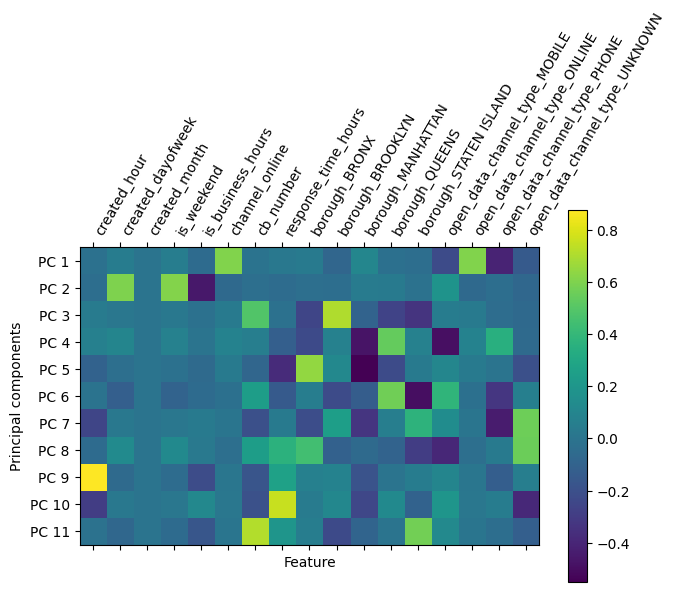

In [ ]:
plt.matshow(pca.components_, cmap='viridis')
plt.yticks(range(pca.n_components_), ['PC {}'.format(i + 1) for i in range(pca.n_components_)])
plt.colorbar()
plt.xticks(range(len(feature_cols)), feature_cols, rotation=60, ha='left')
plt.xlabel('Feature')
plt.ylabel('Principal components')

**Does PCA improve the best Project 2 model?**

The raw features gave a perfect 1.00 on both training and test, same as Project 2. Swapping those out for the 11 PCA components kept training at 1.00 but test accuracy slid down to 0.93. Squeezing 17 features into 11 components shaved off just enough of the `response_time_hours` signal to start missing predictions that the full feature set got right. PCA did not help here.

In [ ]:
# Does PCA improve the best Project 2 model?

from sklearn.model_selection import train_test_split

X_trn, X_tst, y_trn, y_tst = train_test_split(X_train_scaled, y, test_size=0.2, stratify=y, random_state=42)

pca_cmp = PCA(n_components=0.95)
X_trn_pca = pca_cmp.fit_transform(X_trn)
X_tst_pca = pca_cmp.transform(X_tst)

rf = RandomForestClassifier(n_estimators=10, random_state=2).fit(X_trn, y_trn)
print('Random Forest — raw scaled features:')
print("Accuracy on training set: {:.2f}".format(rf.score(X_trn, y_trn)))
print("Accuracy on test set: {:.2f}".format(rf.score(X_tst, y_tst)))

rf_pca = RandomForestClassifier(n_estimators=10, random_state=2).fit(X_trn_pca, y_trn)
print('\nRandom Forest — PCA-reduced features (95% variance):')
print("Accuracy on training set: {:.2f}".format(rf_pca.score(X_trn_pca, y_trn)))
print("Accuracy on test set: {:.2f}".format(rf_pca.score(X_tst_pca, y_tst)))

Random Forest — raw scaled features:
Accuracy on training set: 1.00
Accuracy on test set: 1.00

Random Forest — PCA-reduced features (95% variance):
Accuracy on training set: 1.00
Accuracy on test set: 0.93


## Step 3: Three Clustering Algorithms

## 1. K-Means

The elbow plot shows inertia dropping fast between k=2 and k=5, then flattening out. That bend around k=5 is where adding another cluster stops pulling the score down by much, making it the natural cutoff. k=5 gets used for both the raw and PCA runs.

Both plots show K-Means with k=5, one on the raw scaled features and one on the PCA-reduced features. The overall shape is nearly identical in both: three clusters pile up on the left side and two sit separately on the right, with a wide gap between them. The diagonal stripe pattern running through each group comes from the discrete nature of features like `created_hour` and `created_dayofweek`.

The scores tell the same story on both runs. ARI lands at -0.0008, which is as close to zero as it gets, meaning neither version produced clusters with any real connection to the resolution outcome. The silhouette nudges slightly higher on the PCA version, 0.2370 versus 0.2189, suggesting the groups are marginally better separated in the reduced space, but the difference is small enough to not mean much.

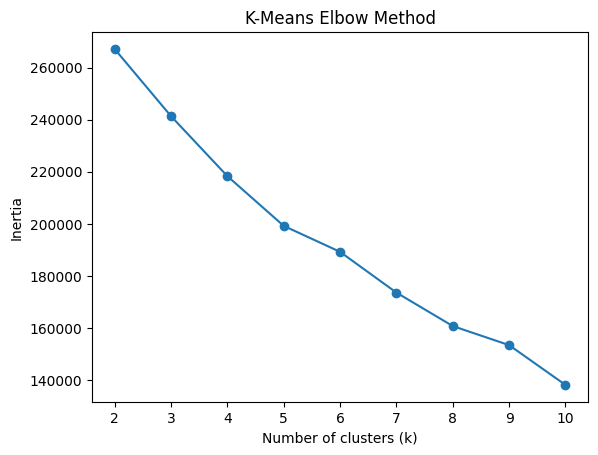

Using k=5


In [ ]:
inertiaVals = {}
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_train_scaled)
    inertiaVals[k] = km.inertia_
plt.figure()
plt.plot(list(inertiaVals.keys()), list(inertiaVals.values()), 'o-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('K-Means Elbow Method')
plt.show()
best_k = 5
print('Using k={}'.format(best_k))

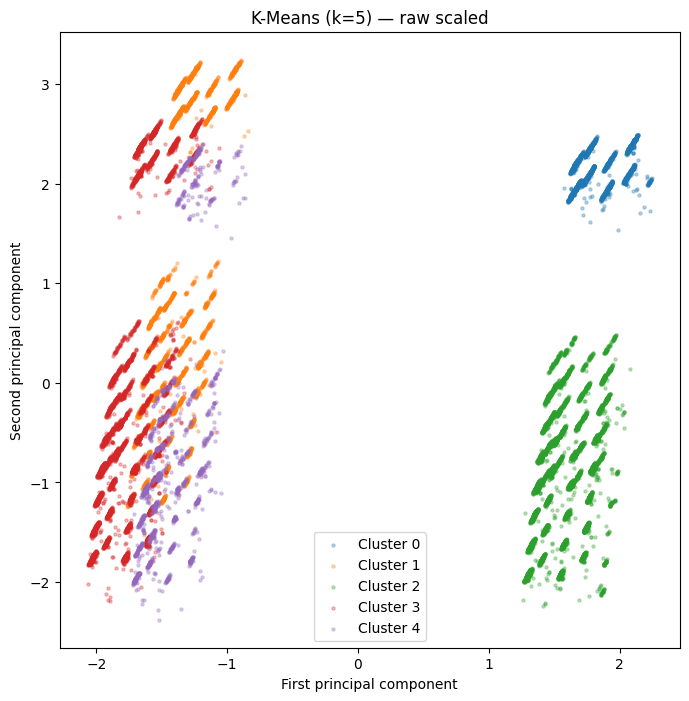

ARI: -0.0008
Silhouette: 0.2189


In [ ]:
km_raw = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_raw.fit(X_train_scaled)
labels_km_raw = km_raw.labels_
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 8))
for c in np.unique(labels_km_raw):
    mask = labels_km_raw == c
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], alpha=0.3, s=5, label='Cluster {}'.format(c))
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('K-Means (k={}) — raw scaled'.format(best_k))
plt.legend(loc='best')
plt.show()
ari_km_raw = adjusted_rand_score(y, labels_km_raw)
sil_km_raw = silhouette_score(X_train_scaled, labels_km_raw, sample_size=5000, random_state=42)
print('ARI: {:.4f}'.format(ari_km_raw))
print('Silhouette: {:.4f}'.format(sil_km_raw))

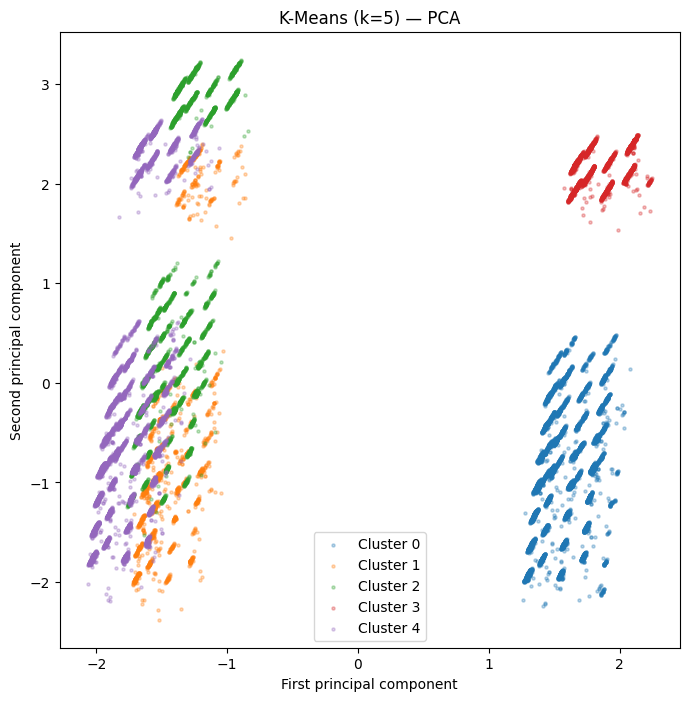

ARI: -0.0008
Silhouette: 0.2370


In [ ]:
km_pca = KMeans(n_clusters=best_k, random_state=42, n_init=10)
km_pca.fit(X_train_pca)
labels_km_pca = km_pca.labels_
plt.figure(figsize=(8, 8))
for c in np.unique(labels_km_pca):
    mask = labels_km_pca == c
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], alpha=0.3, s=5, label='Cluster {}'.format(c))
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('K-Means (k={}) — PCA'.format(best_k))
plt.legend(loc='best')
plt.show()
ari_km_pca = adjusted_rand_score(y, labels_km_pca)
sil_km_pca = silhouette_score(X_train_pca, labels_km_pca, sample_size=5000, random_state=42)
print('ARI: {:.4f}'.format(ari_km_pca))
print('Silhouette: {:.4f}'.format(sil_km_pca))

**2. Agglomerative / Hierarchical**

Agglomerative clustering starts with every point as its own group and works upward, merging the closest pair at each step until everything connects into one tree.

The dendrogram uses a 2,000-point subsample and Ward linkage, which merges pairs of clusters by minimising the increase in total within-cluster variance at each step. The two tallest branches at the top sit well above everything below them, which points clearly to k=2 as the natural cut. Everything below that height merges at much smaller distances, so splitting into more than two groups would be forcing structure that is not really there.

Both scatter plots, raw and PCA, show the same two-cluster split: one large blue group on the left and an orange group on the right, with the same diagonal stripe pattern seen in K-Means. The ARI sits at -0.0023 on raw features and -0.0024 on PCA, both effectively zero. Silhouette scores of 0.1669 and 0.1800 are lower than K-Means produced, meaning the two groups are less geometrically separated than five were. Agglomerative clustering arrived at a different partition from K-Means but landed in exactly the same place in terms of what matters: no meaningful connection to the resolution outcome.

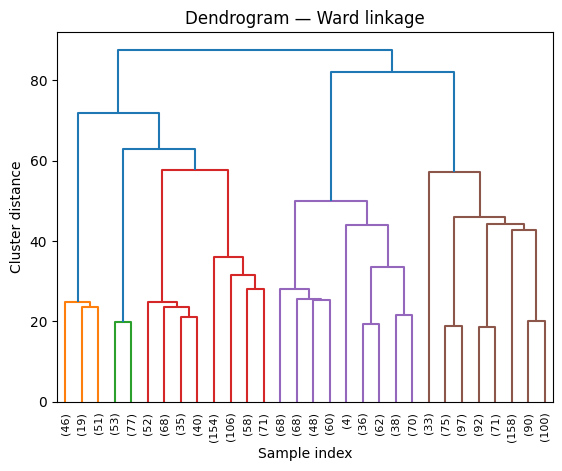

Using k=2


In [ ]:
from scipy.cluster.hierarchy import dendrogram, ward
np.random.seed(42)
sub_idx = np.random.choice(len(X_train_scaled), size=2000, replace=False)
X_sub = X_train_scaled[sub_idx]
linkage_array = ward(X_sub)
dendrogram(linkage_array, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=8)
plt.title('Dendrogram: Ward linkage')
plt.xlabel('Sample index')
plt.ylabel('Cluster distance')
plt.show()
HIER_K = 2
print('Using k={}'.format(HIER_K))

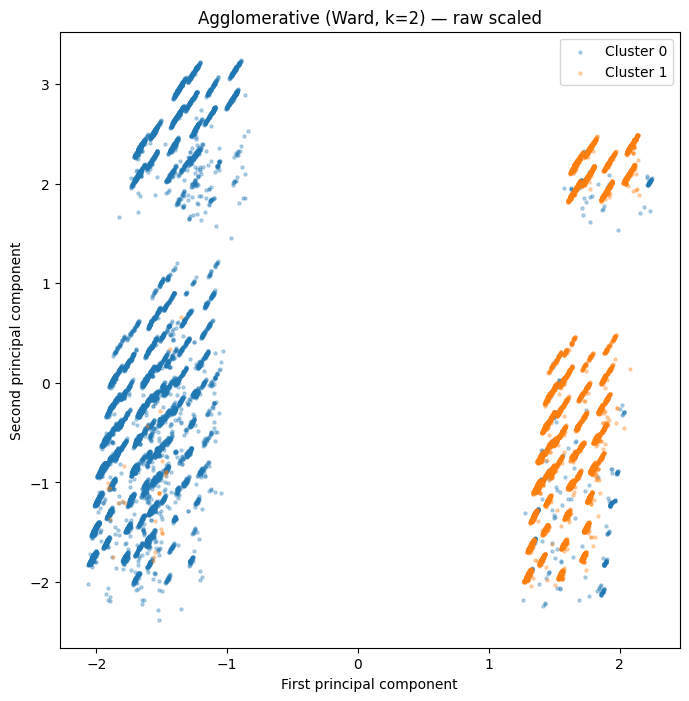

ARI: -0.0023
Silhouette: 0.1669


In [ ]:
agg_raw = AgglomerativeClustering(n_clusters=HIER_K, linkage='ward')
labels_agg_raw = agg_raw.fit_predict(X_train_scaled)
plt.figure(figsize=(8, 8))
for c in np.unique(labels_agg_raw):
    mask = labels_agg_raw == c
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], alpha=0.3, s=5, label='Cluster {}'.format(c))
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('Agglomerative (Ward, k={}) — raw scaled'.format(HIER_K))
plt.legend(loc='best')
plt.show()
ari_agg_raw = adjusted_rand_score(y, labels_agg_raw)
sil_agg_raw = silhouette_score(X_train_scaled, labels_agg_raw, sample_size=5000, random_state=42)
print('ARI: {:.4f}'.format(ari_agg_raw))
print('Silhouette: {:.4f}'.format(sil_agg_raw))

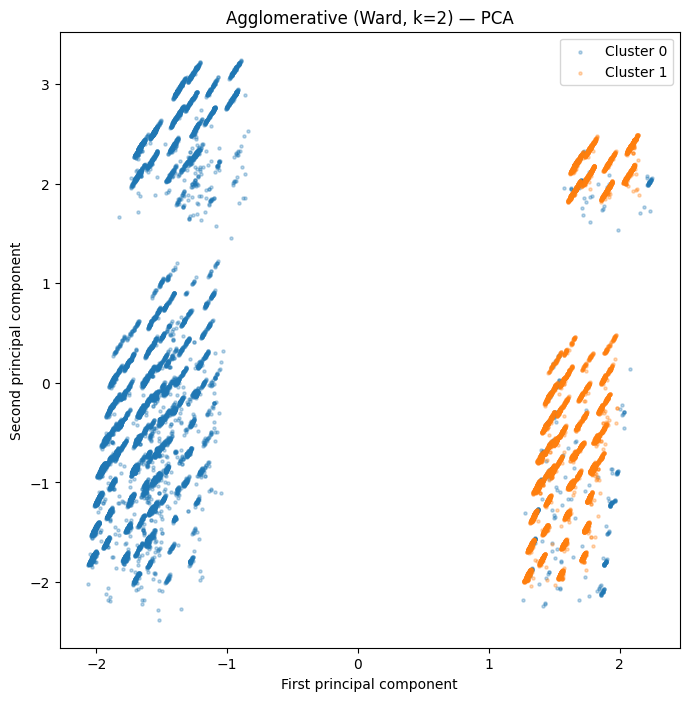

ARI: -0.0024
Silhouette: 0.1800


In [ ]:
agg_pca = AgglomerativeClustering(n_clusters=HIER_K, linkage='ward')
labels_agg_pca = agg_pca.fit_predict(X_train_pca)
plt.figure(figsize=(8, 8))
for c in np.unique(labels_agg_pca):
    mask = labels_agg_pca == c
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], alpha=0.3, s=5, label='Cluster {}'.format(c))
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('Agglomerative (Ward, k={}) — PCA'.format(HIER_K))
plt.legend(loc='best')
plt.show()
ari_agg_pca = adjusted_rand_score(y, labels_agg_pca)
sil_agg_pca = silhouette_score(X_train_pca, labels_agg_pca, sample_size=5000, random_state=42)
print('ARI: {:.4f}'.format(ari_agg_pca))
print('Silhouette: {:.4f}'.format(sil_agg_pca))

**3. DBSCAN**

DBSCAN takes a different approach entirely. Rather than being told how many clusters to find, it figures out groupings on its own by looking at how densely points are packed together. Any point with at least min_samples neighbors within distance eps gets pulled into a cluster. Everything else gets marked as noise.

The default eps=0.5 does not hold up on 17-dimensional scaled data. It broke the dataset into hundreds of micro-clusters, which is not useful. Pushing eps up to 3.0 brought things back to a workable range.

Raw features gave 22 clusters and 105 noise points. PCA came in just slightly lower at 21 clusters and 93 noise points. Both plots show the same two-blob layout that showed up in K-Means and Agglomerative, except now each blob is sliced into a mess of thin diagonal stripes. DBSCAN ended up tracing the density bands that `response_time_hours` creates rather than finding anything structurally different.

ARI of 0.0043 on raw and 0.0042 on PCA are both sitting at essentially zero. The silhouette scores are actually the highest of the three methods, 0.3392 on raw and 0.3873 on PCA. However, there are 22 clusters and each one is just a thin slice of response time. Tight and well-separated clusters are not worth much when the separation does not map onto anything meaningful.

DBSCAN (raw): 22 clusters, 105 noise points


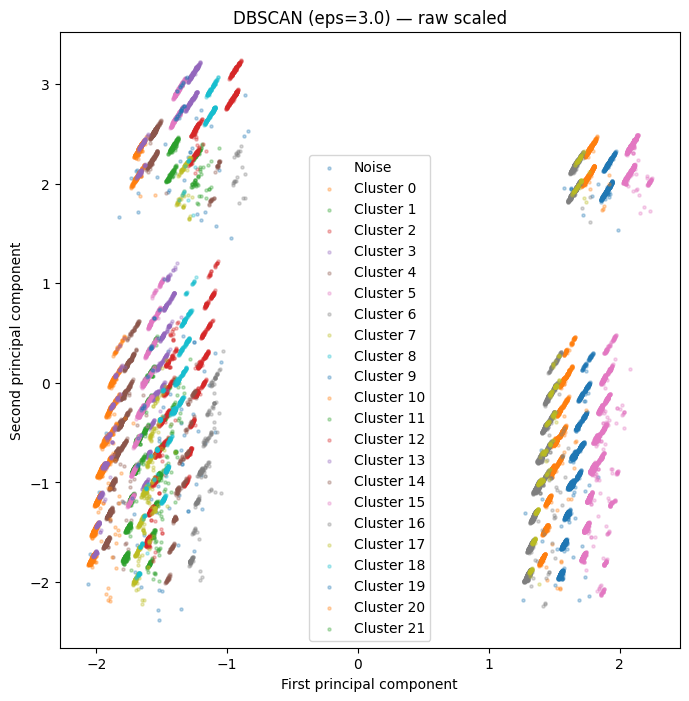

ARI: 0.0043
Silhouette: 0.3392


In [ ]:
EPS = 3.0
db_raw = DBSCAN(min_samples=10, eps=EPS)
labels_db_raw = db_raw.fit_predict(X_train_scaled)
n_clust_raw = len(set(labels_db_raw)) - (1 if -1 in labels_db_raw else 0)
print('DBSCAN (raw): {} clusters, {} noise points'.format(n_clust_raw, (labels_db_raw == -1).sum()))
plt.figure(figsize=(8, 8))
for c in np.unique(labels_db_raw):
    mask = labels_db_raw == c
    lbl = 'Noise' if c == -1 else 'Cluster {}'.format(c)
    plt.scatter(X_pca2[mask, 0], X_pca2[mask, 1], alpha=0.3, s=5, label=lbl)
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('DBSCAN (eps={}) — raw scaled'.format(EPS))
plt.legend(loc='best')
plt.show()
ari_db_raw = adjusted_rand_score(y, labels_db_raw)
if n_clust_raw > 1:
    mask_valid = labels_db_raw != -1
    sil_db_raw = silhouette_score(X_train_scaled[mask_valid], labels_db_raw[mask_valid], sample_size=5000, random_state=42)
else:
    sil_db_raw = float('nan')
print('ARI: {:.4f}'.format(ari_db_raw))
print('Silhouette: {}'.format('{:.4f}'.format(sil_db_raw) if not np.isnan(sil_db_raw) else 'N/A'))

DBSCAN (PCA): 21 clusters, 93 noise points


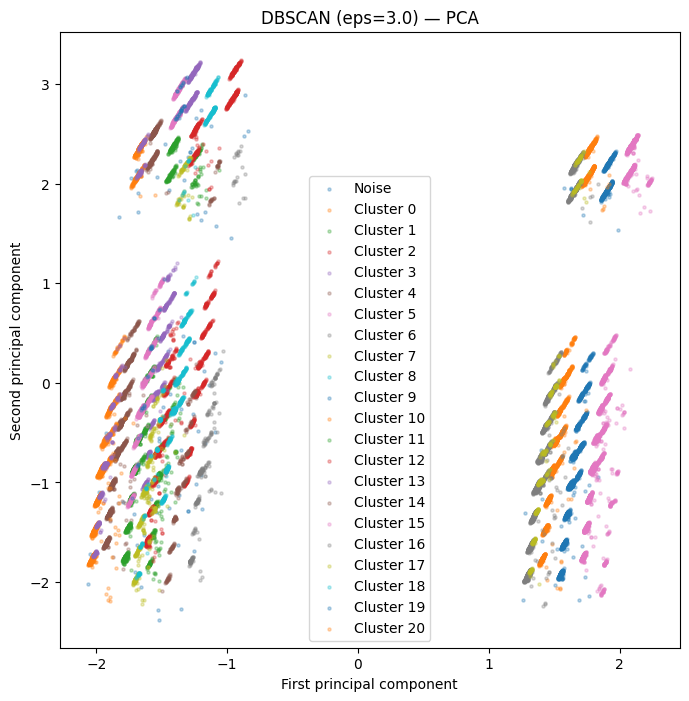

ARI: 0.0042
Silhouette: 0.3873


In [ ]:
db_pca = DBSCAN(min_samples=10, eps=EPS)
labels_db_pca = db_pca.fit_predict(X_train_pca)
n_clust_pca = len(set(labels_db_pca)) - (1 if -1 in labels_db_pca else 0)
print('DBSCAN (PCA): {} clusters, {} noise points'.format(n_clust_pca, (labels_db_pca == -1).sum()))
plt.figure(figsize=(8, 8))
for c in np.unique(labels_db_pca):
    mask = labels_db_pca == c
    lbl = 'Noise' if c == -1 else 'Cluster {}'.format(c)
    plt.scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], alpha=0.3, s=5, label=lbl)
plt.xlabel('First principal component')
plt.ylabel('Second principal component')
plt.title('DBSCAN (eps={}) — PCA'.format(EPS))
plt.legend(loc='best')
plt.show()
ari_db_pca = adjusted_rand_score(y, labels_db_pca)
if n_clust_pca > 1:
    mask_valid = labels_db_pca != -1
    sil_db_pca = silhouette_score(X_train_pca[mask_valid], labels_db_pca[mask_valid], sample_size=5000, random_state=42)
else:
    sil_db_pca = float('nan')
print('ARI: {:.4f}'.format(ari_db_pca))
print('Silhouette: {}'.format('{:.4f}'.format(sil_db_pca) if not np.isnan(sil_db_pca) else 'N/A'))